In [1]:
import numpy as np
import pandas as pd
from time import time
import math
from scipy.stats import norm
import openpyxl
import random

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
from sklearn.feature_selection import SelectFromModel

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.model_selection import validation_curve
from sklearn.model_selection import LearningCurveDisplay
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

from sklearn.metrics import accuracy_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.path as path
from matplotlib.colors import ListedColormap
from matplotlib import colormaps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

TABHUELIST = np.array([
    '#1BA3C6', '#2CB5C0', '#30BCAD', '#21B087',
    '#33A65C', '#57A337', '#A2B627', '#D5BB21',
    '#F8B620', '#F89217', '#F06719', '#E03426',
    '#EB364A', '#F64971', '#FC719E', '#EB73B3',
    '#CE69BE', '#A26DC2', '#7873C0', '#4F7CBA'])
EDGECOLOR = "#051C61"
LIGHTGRAY = "#D3D3D3"

In [2]:
class ClassifierFactory():
    __dtc = 'DecisionTreeClassifier'
    __gbc = 'GradientBoostingClassifier'
    __lrc = 'LogisticRegression'
    __rfc = 'RandomForestClassifier'
    __svl = 'SVC(linear)'    # SVM with kernel='linear'
    __svr = 'SVC(rbf)'       # SVM with kernel='rbf'
    __lsv = 'LinearSVC'

    @property
    def dtc(self):
        return self.__dtc

    @property
    def gbc(self):
        return self.__gbc

    @property
    def lrc(self):
        return self.__lrc

    @property
    def rfc(self):
        return self.__rfc

    @property
    def svl(self):
        return self.__svl

    @property
    def svr(self):
        return self.__svr

    @property
    def lsv(self):
        return self.__lsv

    def newclassifier(self, name, hparams):
        """
        Acting as a factory method, new a classification model with the hyperparameters specified by hparams.

        :param name: str,
            Name of the model to be instantiated.

        :param hparams: dictionary,
            Hyperparameters passed to the model at the creation.
            Contains pairs of hyperparameter names and values.

        :return:
            model: object, Instance of the model |
            desc: str, description of the model
        """
        
        strcriterion = 'criterion'
        strmax_depth = 'max_depth'
        strrandom_state = 'random_state' 
        
        strn_estimators = 'n_estimators'
        strlearning_rate = 'learning_rate'
        
        strmax_iter = 'max_iter'
        
        # SVC
        strkernel = 'kernel'
        
        # LinearSVC
        strdual = 'dual'

        # DecisionTreeClassifier
        if name == self.dtc:
            pcriterion = 'gini'
            pmax_depth = None
            prandom_state = None
            
            if strcriterion in hparams:
                pcriterion = hparams.get(strcriterion)
                # pcriterion = hparams[strcriterion]
            if strmax_depth in hparams:
                pmax_depth = hparams.get(strmax_depth)
            if strrandom_state in hparams:
                prandom_state = hparams.get(strrandom_state)

            desc = f'{name}(criterion={pcriterion}, max_depth={pmax_depth}, random_state={prandom_state})'

            model = DecisionTreeClassifier(criterion=pcriterion,
                                           max_depth=pmax_depth,
                                           random_state=prandom_state
                                           )
        # GradientBoostingClassifier
        elif name == self.gbc:
            pn_estimators = 100
            plearning_rate = 0.1
            prandom_state = None
            
            if strn_estimators in hparams:
                pn_estimators = hparams.get(strn_estimators)            
            if strlearning_rate in hparams:
                plearning_rate = hparams.get(strlearning_rate)            
            if strrandom_state in hparams:
                prandom_state = hparams.get(strrandom_state)

            desc = f'{name}(learning_rate={plearning_rate}, n_estimators={pn_estimators}, random_state={prandom_state}, )'

            model = GradientBoostingClassifier(learning_rate=plearning_rate,
                                               n_estimators=pn_estimators,
                                               random_state=prandom_state                                               
                                               )
        # LogisticRegression
        elif name == self.lrc:
            pmax_iter = 100
            prandom_state = None
            
            if strmax_iter in hparams:
                pmax_iter = hparams.get(strmax_iter)                
            if strrandom_state in hparams:
                prandom_state = hparams.get(strrandom_state)

            desc = f'{name}(max_iter={pmax_iter}, random_state={prandom_state})'

            model = LogisticRegression(max_iter=pmax_iter,
                                       random_state=prandom_state
                                       )
        # RandomForestClassifier
        elif name == self.rfc:
            pn_estimators = 100
            prandom_state = None
            
            if strn_estimators in hparams:
                pn_estimators = hparams.get(strn_estimators)               
            if strrandom_state in hparams:
                prandom_state = hparams.get(strrandom_state)

            desc = f'{name}(n_estimators={pn_estimators}, random_state={prandom_state})'

            model = RandomForestClassifier(n_estimators=pn_estimators,
                                           random_state=prandom_state
                                           )
        # Support Vector Machine Classifier (SVC)
        elif name == self.svl or name == self.svr:
            pmax_iter = -1
            prandom_state = None
            
            if name == self.svl:
                pkernel = 'linear'
            elif name == self.svr:
                pkernel = 'rbf'
            else:
                pkernel = 'poly'
                
            if strmax_iter in hparams:
                pmax_iter = hparams.get(strmax_iter)                
            if strrandom_state in hparams:
                prandom_state = hparams.get(strrandom_state)

            desc = f'{name}(kernel={pkernel}, max_iter={pmax_iter}, random_state={prandom_state})'

            model = SVC(kernel=pkernel,
                        max_iter=pmax_iter,
                        random_state=prandom_state
                        )
        # LinearSVC
        elif name == self.lsv:
            pdual = 'auto'
            pmax_iter = 1000
            prandom_state = None
            
            if strdual in hparams:
                pdual = hparams.get(strdual)
            if strmax_iter in hparams:
                pmax_iter = hparams.get(strmax_iter)                
            if strrandom_state in hparams:
                prandom_state = hparams.get(strrandom_state)

            desc = f'{name}(dual={pdual}, max_iter={pmax_iter}, random_state={prandom_state})'

            model = LinearSVC(random_state=prandom_state,
                              max_iter=pmax_iter,
                              dual=pdual
                              )
        # Undefined
        else:
            desc = f'{name} is not implemented as of now'
            model = None

        return model, desc

    def execute(self, model, x_train, y_train, x_test, y_test):
        """
        Calls fit and predict and score on the model.
        Computes accuracy score for the training data and the test data

        :param model: instance of the model
        :param x_train: the training features
        :param y_train: the training labels
        :param x_test: the test features
        :param y_test: the test labels
        :return: score_model: float, score of the test data |
            acc_train: float, accuracy score of the training data |
            acc_test: float, accuracy score of the test data |
            acc_all: float, accuracy score of the entire data
        """
        score_model = None
        acc_train = None
        acc_test = None
        acc_all = None

        if model is not None:
            # learning
            model.fit(x_train, y_train)

            # predict
            y_test_pred = model.predict(x_test)
            y_train_pred = model.predict(x_train)
            
            # evaluate the trained model on the entire dataset
            x = np.vstack([x_train, x_test])
            y = np.hstack([y_train, y_test])
            y_pred = model.predict(x)

            # evaluate
            score_model = model.score(x_test, y_test) # the same as the score of the test data
            acc_train = accuracy_score(y_train, y_train_pred)
            acc_test = accuracy_score(y_test, y_test_pred)
            acc_all = accuracy_score(y, y_pred)

        return score_model, acc_train, acc_test, acc_all

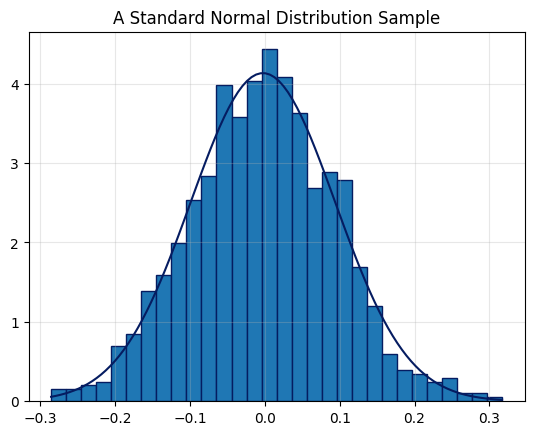

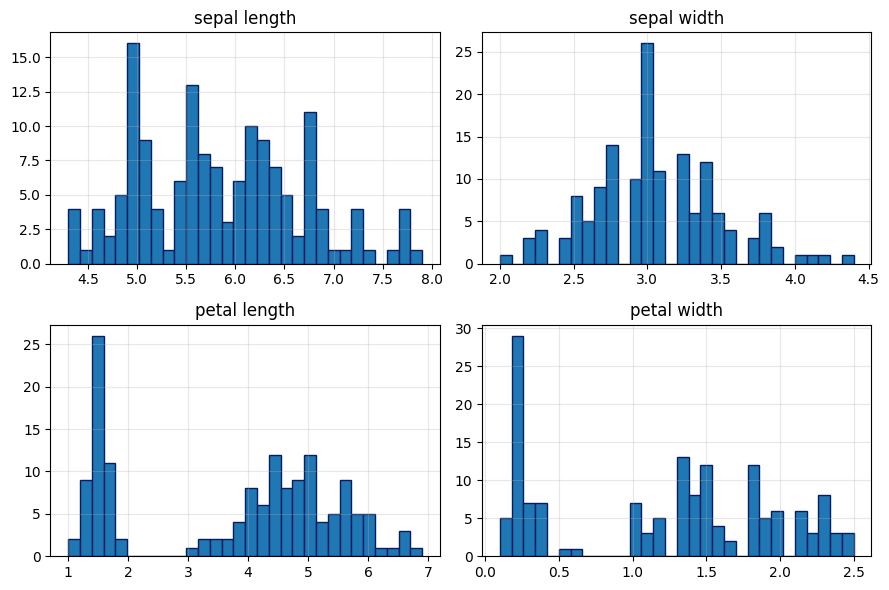

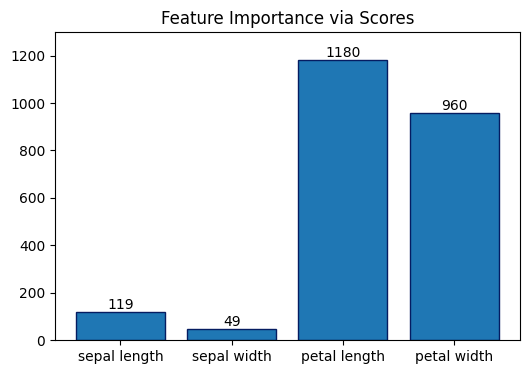

Feature scores: [ 119  49  1180  960]
Done in 0.000s
Features Selected by SelectFromModel: 
[False False  True  True]
['petal length' 'petal width']
[[0.         0.29718462 0.8813571  0.48543859]
 [0.         0.46408059 0.64985125 0.65186211]
 [0.32233216 0.33421515 2.204817   1.81858097]]
Max Features: 2
Threshold: 1e-05

Classes: ['setosa' 'versicolor' 'virginica']
Importance: 
[[0.   0.3  0.88 0.49]
 [0.   0.46 0.65 0.65]
 [0.32 0.33 2.2  1.82]]


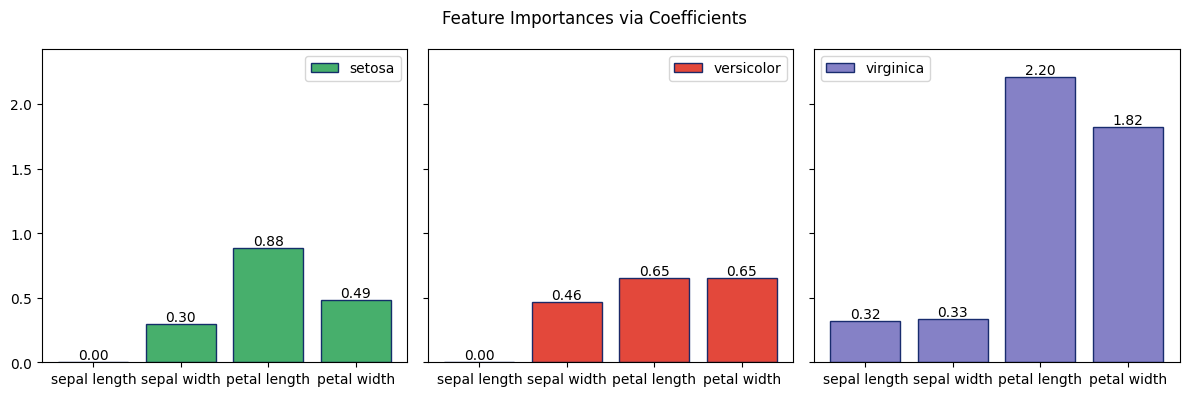

Features Selected by SelectFromModel: [False False  True  True]


In [13]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

BINS = 30
# 
# normal distribution
# Parameters
mu = 0       # mean
sigma = 0.1  # standard deviation
n = 1000     # number of samples

# 1. Generate data
data = np.random.normal(mu, sigma, n)
# 2. Fit normal distribution to the data
mu, std = norm.fit(data)
# 3. Create the curve
xmin, xmax = data.min(), data.max()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

plt.hist(data, bins=BINS, density=True, edgecolor=EDGECOLOR)
plt.plot(x, p, color=EDGECOLOR)
plt.grid(which='major', alpha=0.3)
plt.title("A Standard Normal Distribution Sample")
plt.show()

#
# Iris features distribution
iris = load_iris()
X, y = iris.data, iris.target

feature_names = np.char.replace(iris.feature_names, ' (cm)', '')
df = pd.DataFrame(X, columns=feature_names)
# print(df.head())

#-------------------------------------------------------
fig, subs = plt.subplots(2, 2, 
                         figsize=(9, 6))
axes = subs.flatten()

for i in np.arange(len(axes)):
    axes[i].hist(df.iloc[:, i], bins=BINS, edgecolor=EDGECOLOR)
    axes[i].set_title(feature_names[i])
    axes[i].grid(which='major', alpha=0.3)
plt.tight_layout()
plt.show()

prandom_state = 0

#
# Univariate feature selection
#
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif, chi2

skb = SelectKBest(
    f_classif,
    # chi2,
    k=4).fit(X, y)
X_new = skb.transform(X)    #get the target features but without transformation
# print(X_new[0:5])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(height=skb.scores_, x=feature_names, edgecolor=EDGECOLOR)
ax.set_ylim(top=np.max(skb.scores_)*1.1)
ax.bar_label(bars, fmt='%.0f')
ax.set_title("Feature Importance via Scores")
plt.show()

with np.printoptions(formatter={'float': '{: 0.0f}'.format}, suppress=True):
    print(f'Feature scores: {skb.scores_}')
# print(f'select features: {feature_names[skb.get_support()]}')

#
# Feature selection from SelectFromModel
#
# Feature importance from coefficients
X = StandardScaler().fit_transform(X)

# threshold = np.sort(importance)[-3] + 0.01
max_features = 2

tic = time()
linsvc = LinearSVC(dual='auto', penalty='l1', C=1.0, max_iter=3000, random_state=prandom_state)
lr = LogisticRegression(max_iter=3000, random_state=prandom_state)    #l1_ratio=1, C=1.0, 

sfm = SelectFromModel(linsvc, 
                      # threshold='mean', 
                      max_features=max_features).fit(X, y)
estim = sfm.estimator_
toc = time()
print(f"Done in {toc - tic:.3f}s")
print(f"Features Selected by SelectFromModel: \n{sfm.get_support()}\n{feature_names[sfm.get_support()]}")
print(abs(estim.coef_))
print(f"Max Features: {sfm.max_features_}")
print(f"Threshold: {sfm.threshold_}")

classes = estim.classes_
classnames = iris.target_names[classes]
print(f'\nClasses: {classnames}')
importance = np.abs(estim.coef_)
print(f'Importance: \n{importance.round(2)}')
_, (ax1, ax2, ax3) = plt.subplots(1, 3, 
                                  sharex="row", 
                                  sharey="row", 
                                  figsize=(12, 4))
plt.subplots_adjust(bottom=0.15)

xnames = feature_names   #["Sepal Length", "Width", "Petal Length", " Width"]
colors = TABHUELIST[4:20:7]
bars1 = ax1.bar(height=importance[classes[0]], x=xnames, label=classnames[0], 
                color=colors[0], alpha=0.9, edgecolor=EDGECOLOR)
ax1.bar_label(bars1, fmt='%.2f')
bars2 = ax2.bar(height=importance[classes[1]], x=xnames, label=classnames[1], 
                color=colors[1], alpha=0.9, edgecolor=EDGECOLOR)
ax2.bar_label(bars2, fmt='%.2f')
bars3 = ax3.bar(height=importance[classes[2]], x=xnames, label=classnames[2], 
                color=colors[2], alpha=0.9, edgecolor=EDGECOLOR)
ax3.set_ylim(top=np.max(importance[classes[2]])*1.1)
ax3.bar_label(bars3, fmt='%.2f')

ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')

# ax1.set_title("Feature importances via coefficients")
# plt.title("Feature importances via coefficients")
_.suptitle("Feature Importances via Coefficients")
plt.tight_layout()
plt.show()
print(f"Features Selected by SelectFromModel: {sfm.get_support()}")


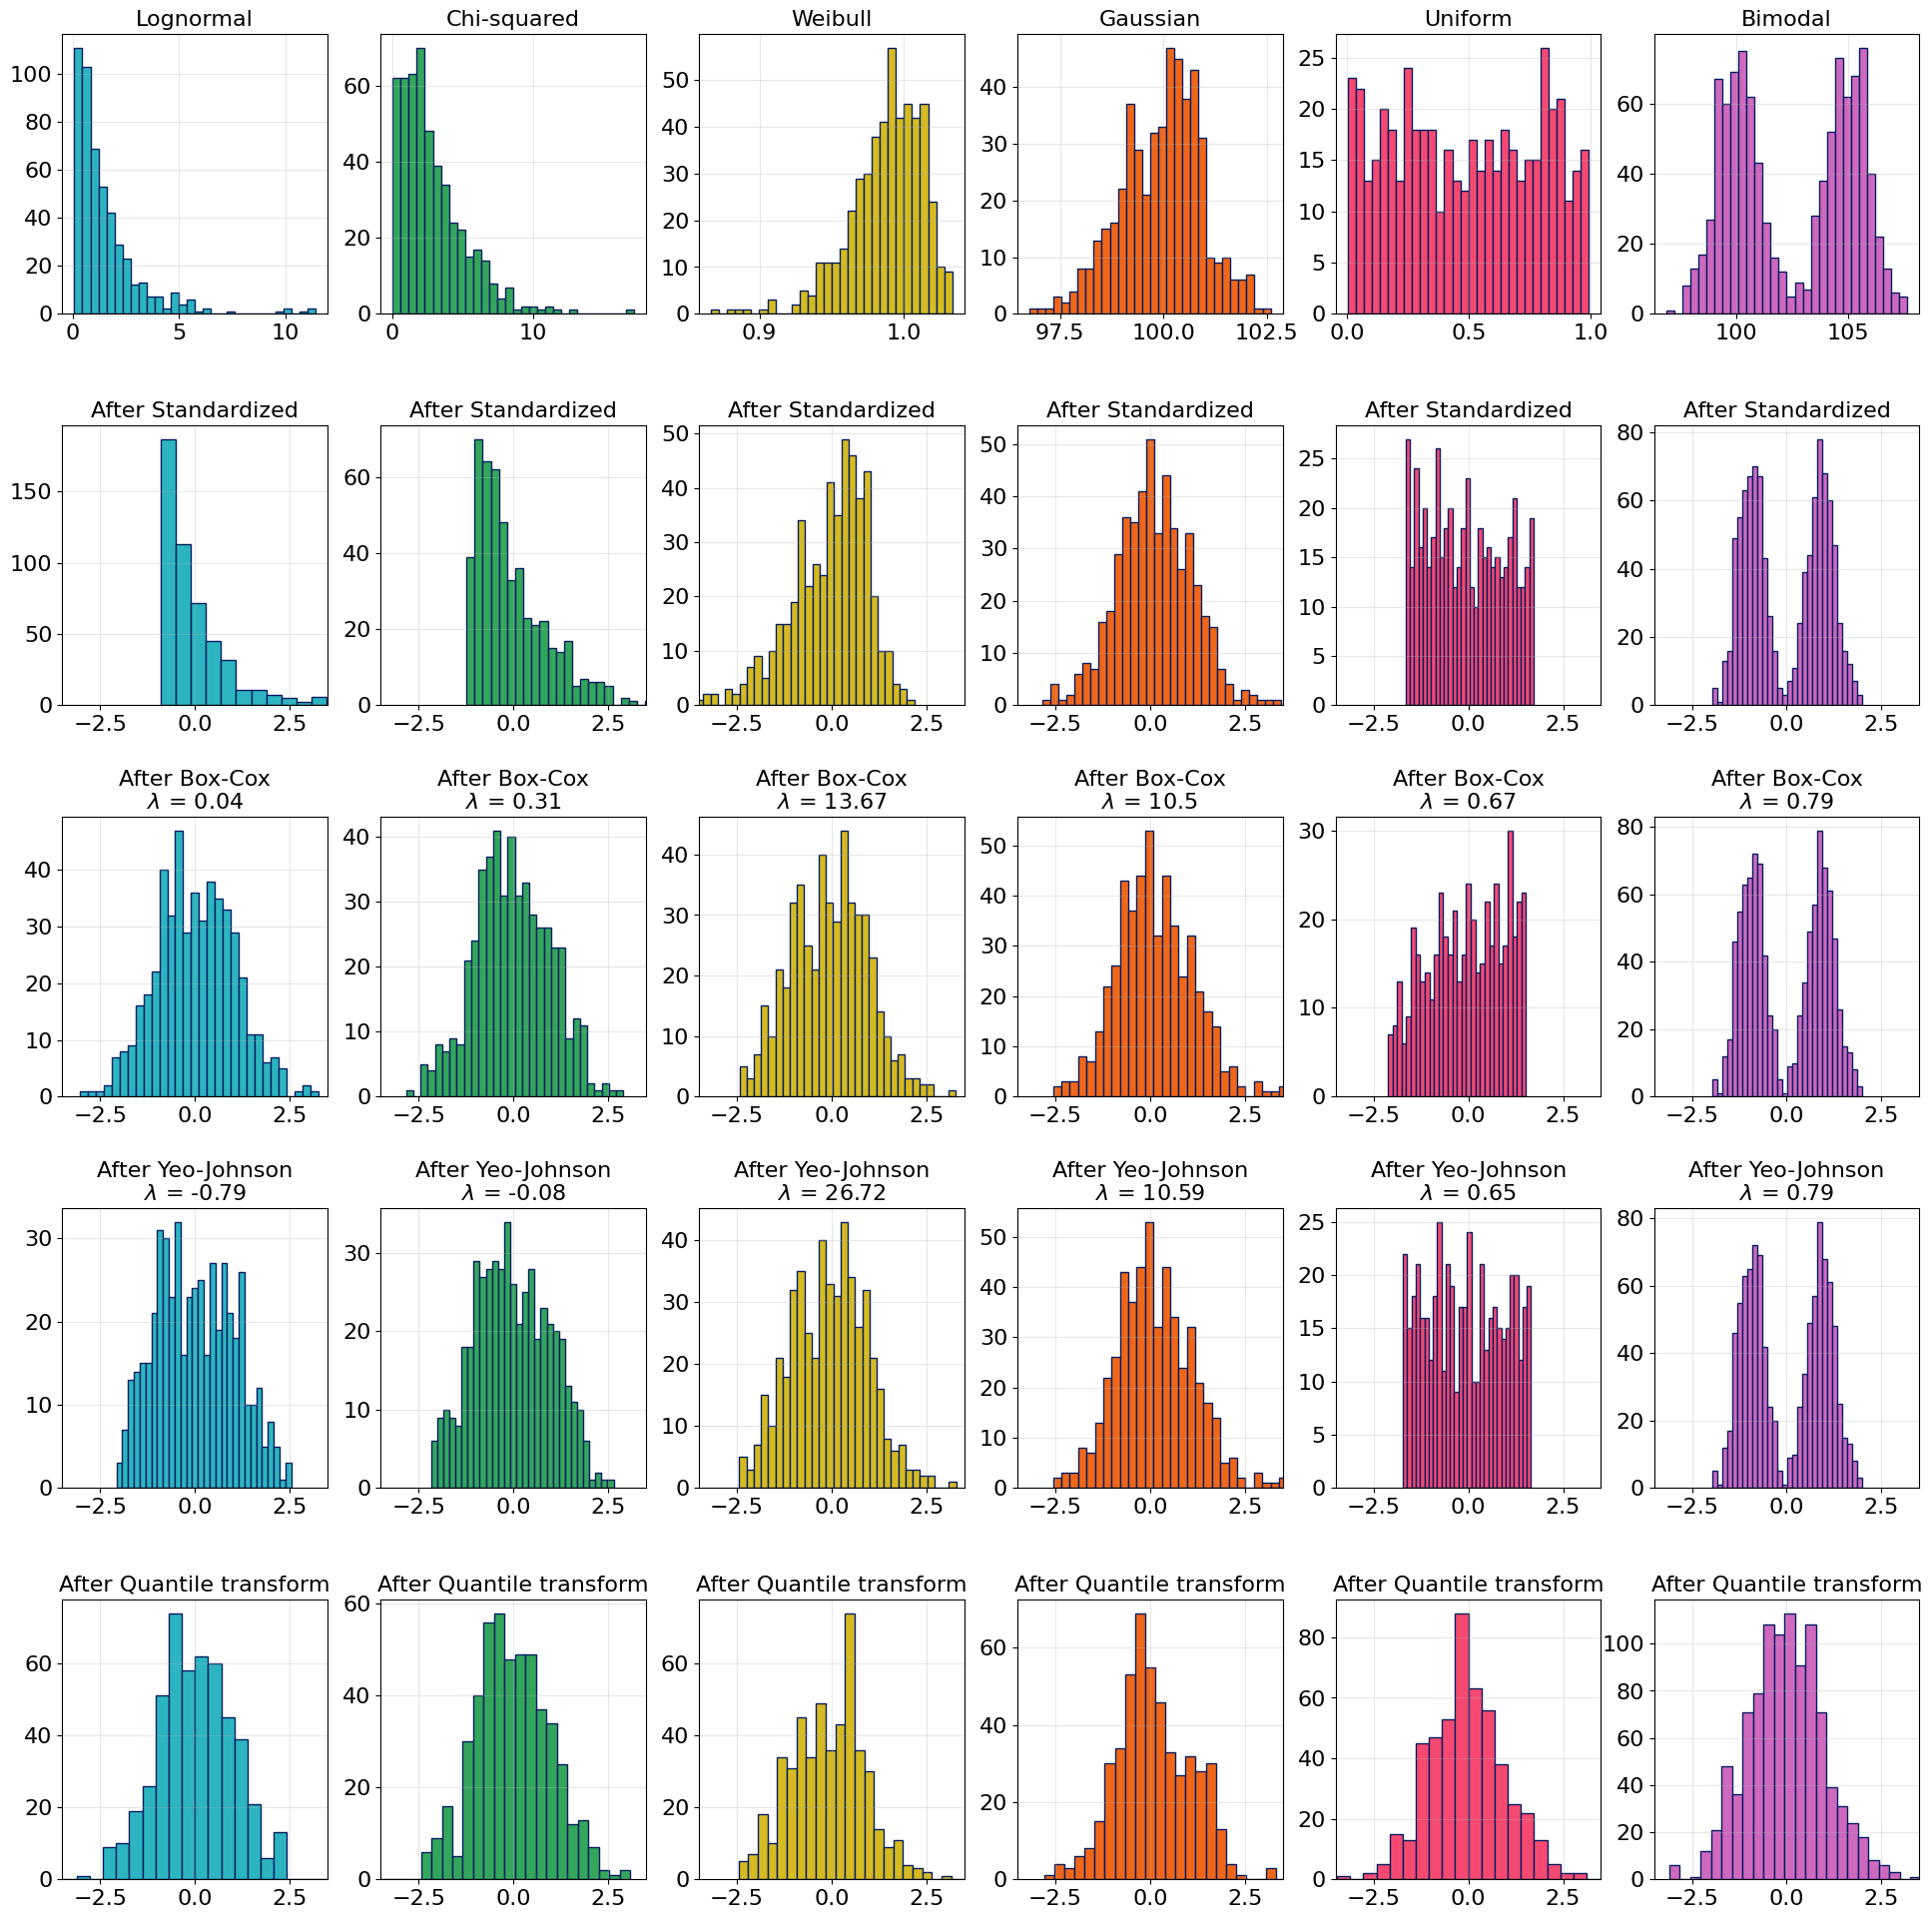

In [7]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

N_SAMPLES = 1000
FONT_SIZE = 16
BINS = 30
ALPHA = 0.3

rng = np.random.RandomState(304)
bc = PowerTransformer(method="box-cox")
yj = PowerTransformer(method="yeo-johnson")
# n_quantiles is set to the training set size rather than the default value
# to avoid a warning being raised by this example
qt = QuantileTransformer(
    n_quantiles=500, output_distribution="normal", random_state=rng
)
ss = StandardScaler()
size = (N_SAMPLES, 1)


# lognormal distribution
X_lognormal = rng.lognormal(size=size)

# chi-squared distribution
df = 3
X_chisq = rng.chisquare(df=df, size=size)

# weibull distribution
a = 50
X_weibull = rng.weibull(a=a, size=size)

# gaussian distribution
loc = 100
X_gaussian = rng.normal(loc=loc, size=size)

# uniform distribution
X_uniform = rng.uniform(low=0, high=1, size=size)

# bimodal distribution
loc_a, loc_b = 100, 105
X_a, X_b = rng.normal(loc=loc_a, size=size), rng.normal(loc=loc_b, size=size)
X_bimodal = np.concatenate([X_a, X_b], axis=0)


# create plots
distributions = [
    ("Lognormal", X_lognormal),
    ("Chi-squared", X_chisq),
    ("Weibull", X_weibull),
    ("Gaussian", X_gaussian),
    ("Uniform", X_uniform),
    ("Bimodal", X_bimodal),
]

cinds = np.arange(1, 20, 3)
colors = [TABHUELIST[ind] for ind in cinds]
edgecolor = EDGECOLOR

fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(24, 24))   #plt.figaspect(6)), layout="constrained"
axes = axes.flatten()
axes_idxs = [
    (0,  6, 12, 18, 24),
    (1,  7, 13, 19, 25),
    (2,  8, 14, 20, 26),
    (3,  9, 15, 21, 27),
    (4, 10, 16, 22, 28),
    (5, 11, 17, 23, 29),
]
axes_list = [(axes[i], axes[j], axes[k], axes[l], axes[m]) for (i, j, k, l, m) in axes_idxs]


for distribution, color, axes in zip(distributions, colors, axes_list):
    name, X = distribution
    X_train, X_test = train_test_split(X, test_size=0.5)
    
    # standard scaling
    X_trans_ss = ss.fit(X_train).transform(X_test)
    
    # perform power transforms and quantile transform
    X_trans_bc = bc.fit(X_train).transform(X_test)
    lmbda_bc = round(bc.lambdas_[0], 2)
    X_trans_yj = yj.fit(X_train).transform(X_test)
    lmbda_yj = round(yj.lambdas_[0], 2)
    X_trans_qt = qt.fit(X_train).transform(X_test)

    ax_original, ax_ss, ax_bc, ax_yj, ax_qt = axes

    ax_original.grid(alpha=ALPHA)
    ax_original.hist(X_train, color=color, bins=BINS, edgecolor=edgecolor)
    ax_original.set_title(name, fontsize=FONT_SIZE)
    ax_original.tick_params(axis="both", which="major", labelsize=FONT_SIZE)

    for ax, X_trans, meth_name, lmbda in zip(
        (ax_ss, ax_bc, ax_yj, ax_qt),
        (X_trans_ss, X_trans_bc, X_trans_yj, X_trans_qt),
        ("Standardized", "Box-Cox", "Yeo-Johnson", "Quantile transform"),
        (None, lmbda_bc, lmbda_yj, None),
    ):
        ax.grid(alpha=ALPHA)
        ax.hist(X_trans, color=color, bins=BINS, edgecolor=edgecolor)
        title = "After {}".format(meth_name)
        if lmbda is not None:
            title += "\n$\\lambda$ = {}".format(lmbda)
        ax.set_title(title, fontsize=FONT_SIZE)
        ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)
        ax.set_xlim([-3.5, 3.5])

# plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

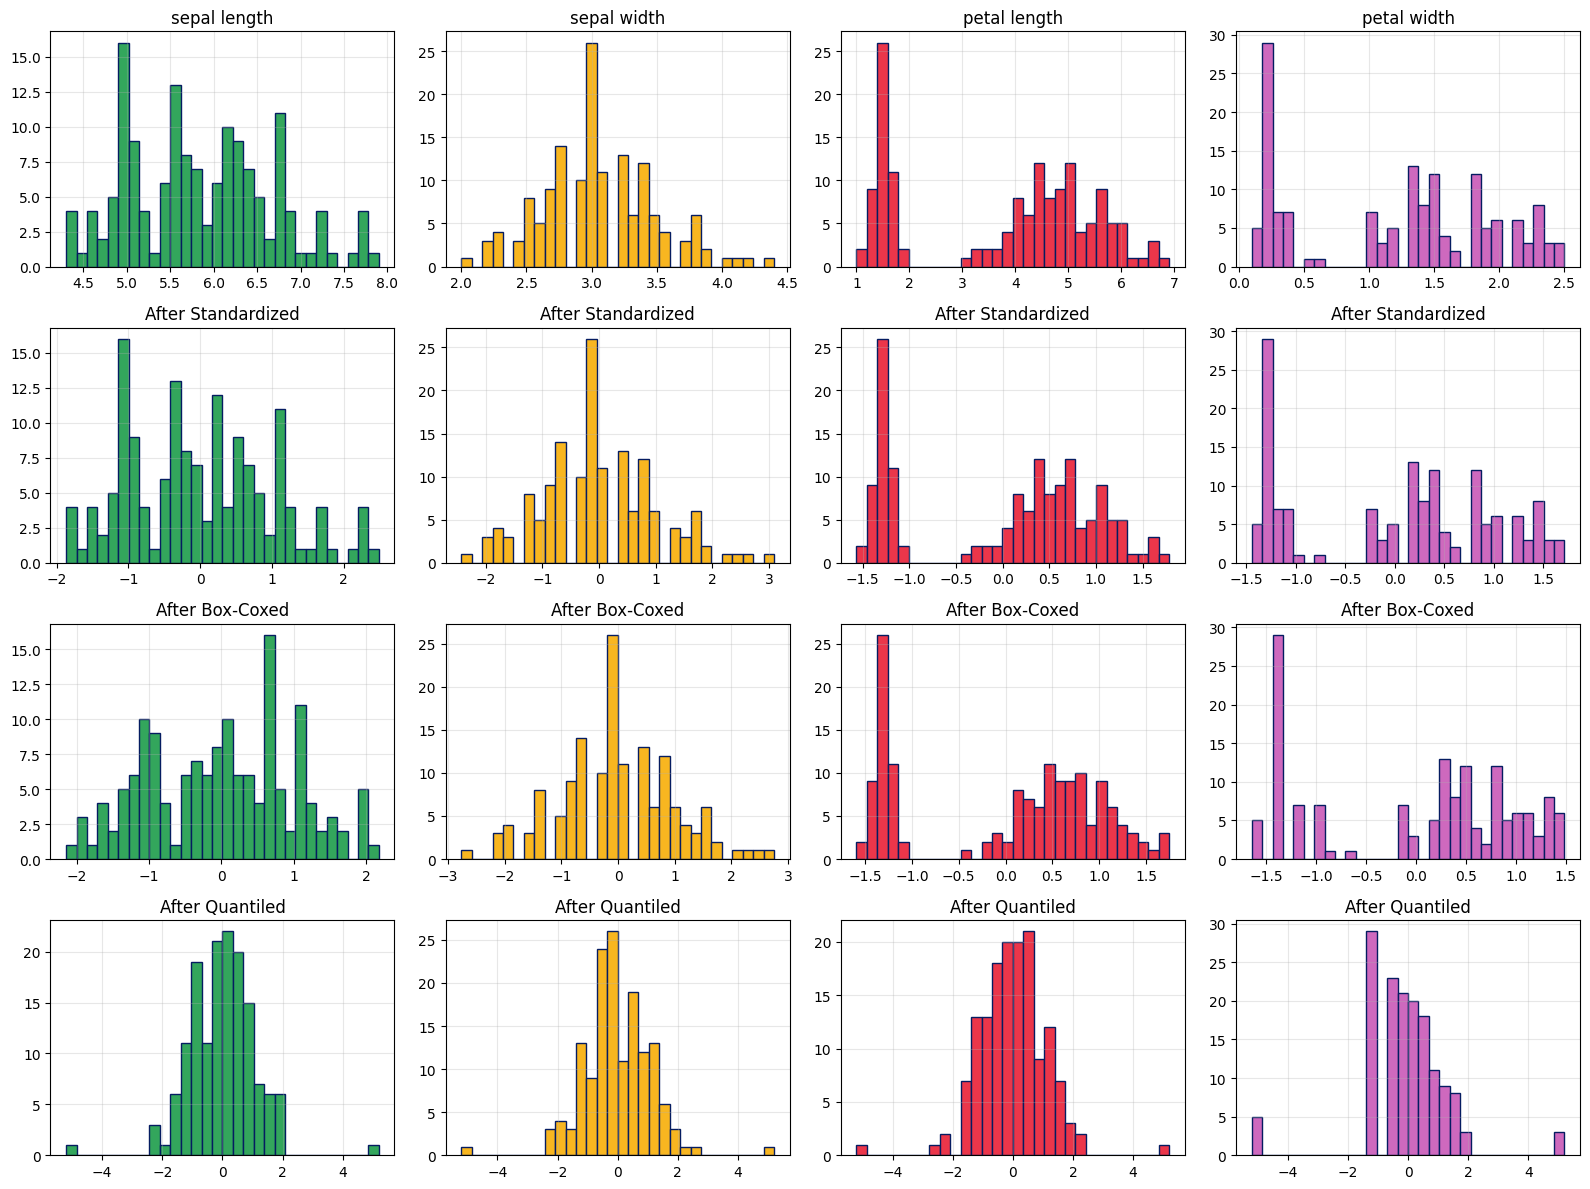

In [8]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = np.char.replace(iris.feature_names, ' (cm)', '')

prandom_state = 0
BINS = 30

fig, subs = plt.subplots(nrows=4, ncols=4, 
                         # sharey="row", 
                         figsize=(16, 12))
axes = subs.flatten()
colors = TABHUELIST[4:20:4]

dfo = pd.DataFrame(X, columns=feature_names)
for i, name in enumerate(feature_names):
    axes[i].hist(dfo[name], bins=BINS, color=colors[i], edgecolor=EDGECOLOR)
    # axes[i].set_xlabel(name)
    axes[i].set_title(name)
    axes[i].grid(which='major', alpha=0.3)
    
#
# Preprocess: Standardize the features
sc = StandardScaler()
xs = sc.fit_transform(X)
dfs = pd.DataFrame(xs, columns=feature_names)
for i, name in enumerate(feature_names):
    axes[4+i].hist(dfs[name], bins=BINS, color=colors[i], edgecolor=EDGECOLOR)
    # axes[4+i].set_xlabel(name)
    axes[4+i].set_title("After Standardized")
    axes[4+i].grid(which='major', alpha=0.3)

#
# Preprocess: Box-Cox the features
pt = PowerTransformer(method='box-cox', standardize=True)
xb = pt.fit_transform(X)
dfb = pd.DataFrame(xb, columns=feature_names)
# print(f"Estimated Lambda value: {pt.lambdas_[0]:.4f}")
for i, name in enumerate(feature_names):
    axes[8+i].hist(dfb[name], bins=BINS, color=colors[i], edgecolor=EDGECOLOR)
    # axes[8+i].set_xlabel(name)
    axes[8+i].set_title("After Box-Coxed")
    axes[8+i].grid(which='major', alpha=0.3)

# n_quantiles is set to the training set size rather than the default value
# to avoid a warning being raised by this example
qt = QuantileTransformer(
    n_quantiles=len(X), 
    output_distribution="normal", 
    random_state=prandom_state
)
xq = qt.fit_transform(X)
dfq = pd.DataFrame(xq, columns=feature_names)
for i, name in enumerate(feature_names):
    axes[12+i].hist(dfq[name], bins=BINS, color=colors[i], edgecolor=EDGECOLOR)
    # axes[12+i].set_xlabel(name)
    axes[12+i].set_title("After Quantiled")
    axes[12+i].grid(which='major', alpha=0.3)
    
plt.tight_layout()
plt.show()


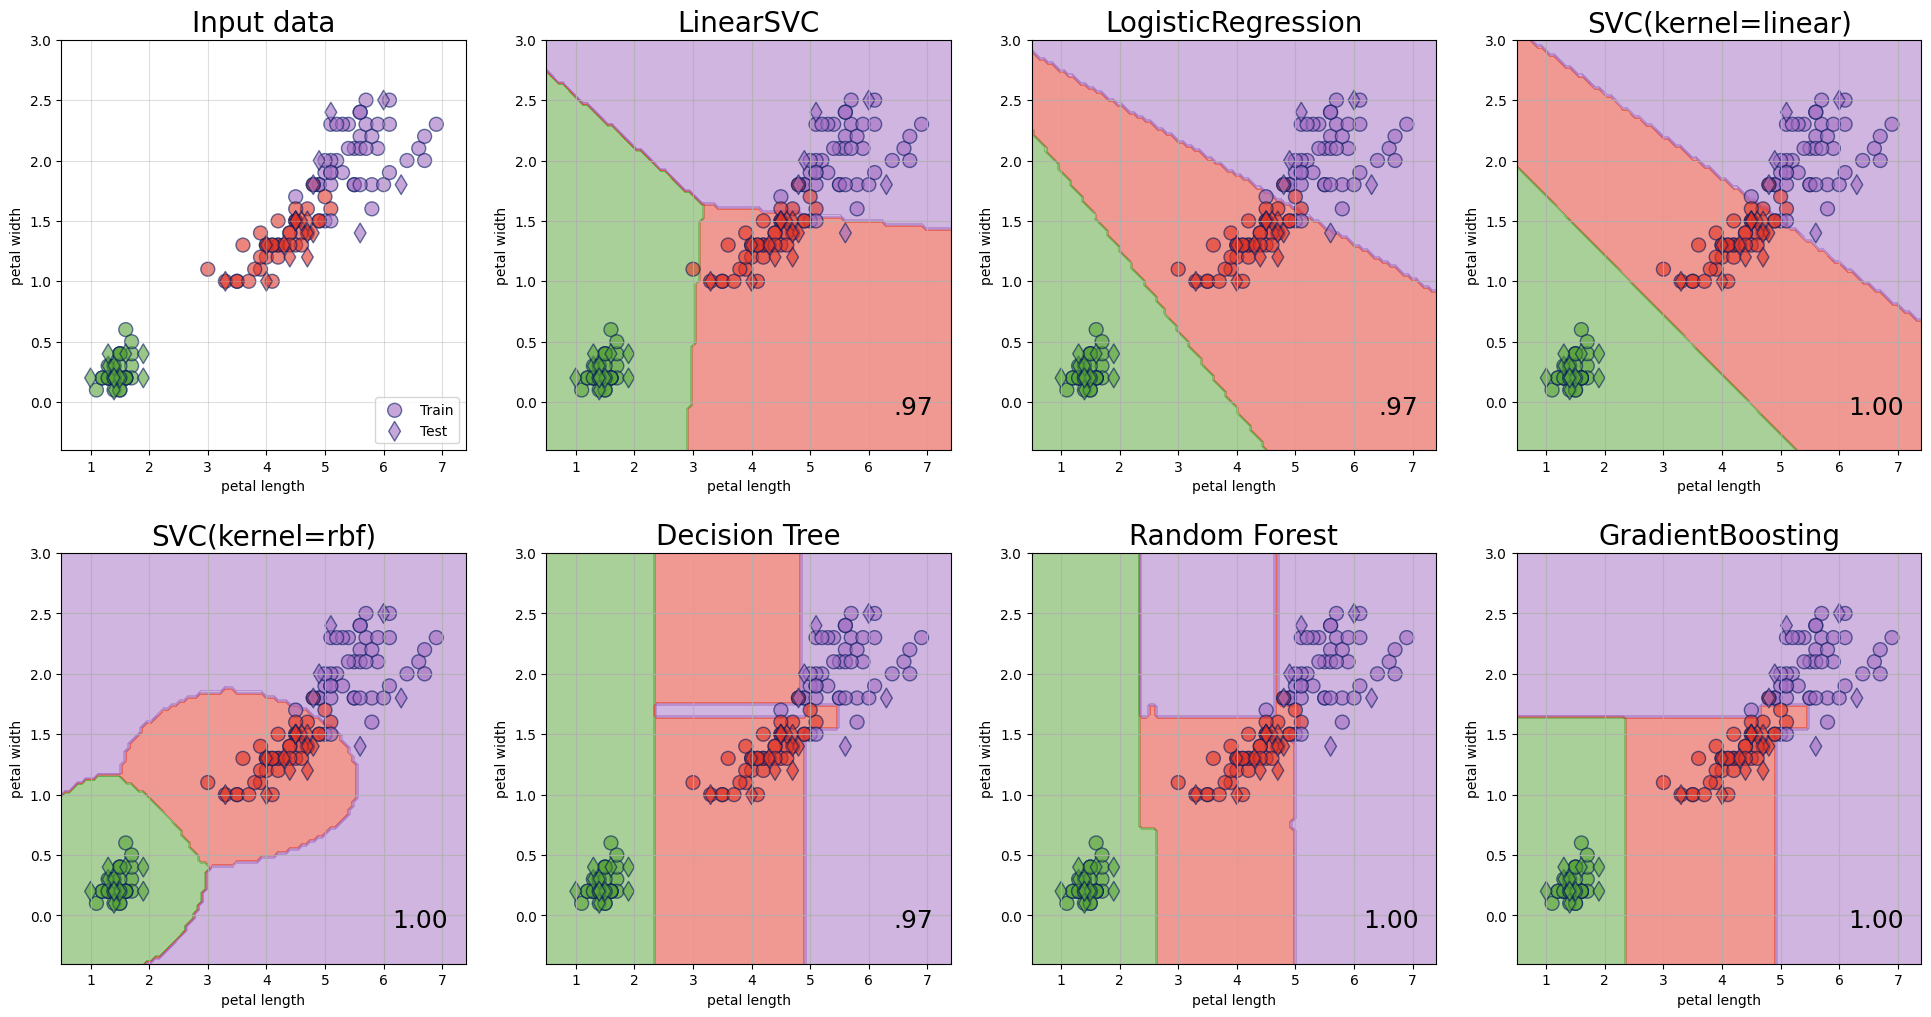

In [12]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

names = [
    "LinearSVC",
    "LogisticRegression",
    "SVC(kernel=linear)",
    "SVC(kernel=rbf)",
    "Decision Tree",
    "Random Forest",
    "GradientBoosting",
]

classifiers = [
    LinearSVC(dual='auto', max_iter=2000, random_state=0),
    LogisticRegression(max_iter=5000, random_state=0),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(kernel='rbf', gamma=2, C=1, random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=None, random_state=42),    #max_features=1
    GradientBoostingClassifier(learning_rate=0.1, random_state=0),
]

# Selected features: petal length and petal width
X, y = load_iris(return_X_y=True)
iris_set = (X[:, 2:4], y)
feature_names = ["petal length", "petal width"]

datasets = [
    iris_set
]

# figure = plt.figure(figsize=(24, 3))
rows, cols = 2, int((len(classifiers) + 1)/2)
fig, axes = plt.subplots(rows, cols, figsize=(24, 12))
titlesize = 20
markersize = 100
edgecolor = EDGECOLOR
markertrain = "o"
markertest = "d"

i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=0, shuffle=True,
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm_bright = ListedColormap(TABHUELIST[5:20:6])
    ax = plt.subplot(rows, cols, i)
    if ds_cnt == 0:
        ax.set_title("Input data", size=titlesize)
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], 
               c=y_train, 
               cmap=cm_bright,
               alpha=0.6,
               edgecolors=edgecolor,
               marker=markertrain,
               label='Train',
               s=markersize)
    
    # Plot the testing points
    ax.scatter(X_test[:, 0], X_test[:, 1], 
               c=y_test, 
               cmap=cm_bright, 
               alpha=0.6, 
               edgecolors=edgecolor,
               marker=markertest,
               label='Test',
               s=markersize)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('petal length')
    ax.set_ylabel('petal width')
    ax.legend(loc='lower right')
    ax.grid(which='major', alpha=0.4)
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):      
        ax = plt.subplot(rows, cols, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, 
            cmap=cm_bright, 
            alpha=0.5, 
            ax=ax, 
            eps=0.5
        )
        
        y_train_pred = clf.predict(X_train)
        y_test_pred = clf.predict(X_test)

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], 
            c=y_train, 
            cmap=cm_bright,
            alpha=0.6,
            edgecolors=edgecolor,
            marker=markertrain,
            s=markersize)
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            alpha=0.6,
            edgecolors=edgecolor,
            marker=markertest,
            s=markersize)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel('petal length')
        ax.set_ylabel('petal width')
        ax.grid(which='major', alpha=0.8)
        if ds_cnt == 0:
            ax.set_title(name, size=titlesize)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=18,
            horizontalalignment="right",
        )
        i += 1

# plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.2)
plt.show()

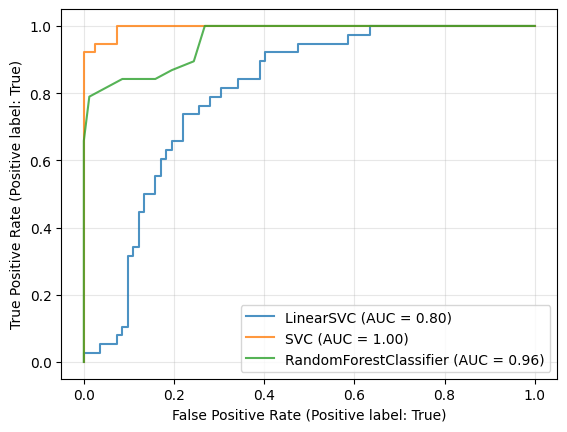

In [16]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

prandom_state = 0
X, y = load_iris(return_X_y=True)
X, y = shuffle(X, y, random_state=prandom_state)

y = y == 1  # make binary

X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=.8, random_state=prandom_state
)
ax = plt.gca()

names = [
    "LinearSVC",
    "SVC(kernel=rbf)",
    "Random Forest",
]    
classifiers = [
    LinearSVC(dual='auto', max_iter=2000, random_state=0),
    SVC(kernel='rbf', gamma=2, C=1, random_state=0),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=None, random_state=0),    #max_features=1
]

for name, clf in zip(names, classifiers):
    clf.fit(X_train, y_train)
    clf_disp = RocCurveDisplay.from_estimator(
        clf, 
        X_test, y_test, 
        ax=ax, 
        alpha=0.8)
    
plt.grid(alpha=0.3)
plt.show()

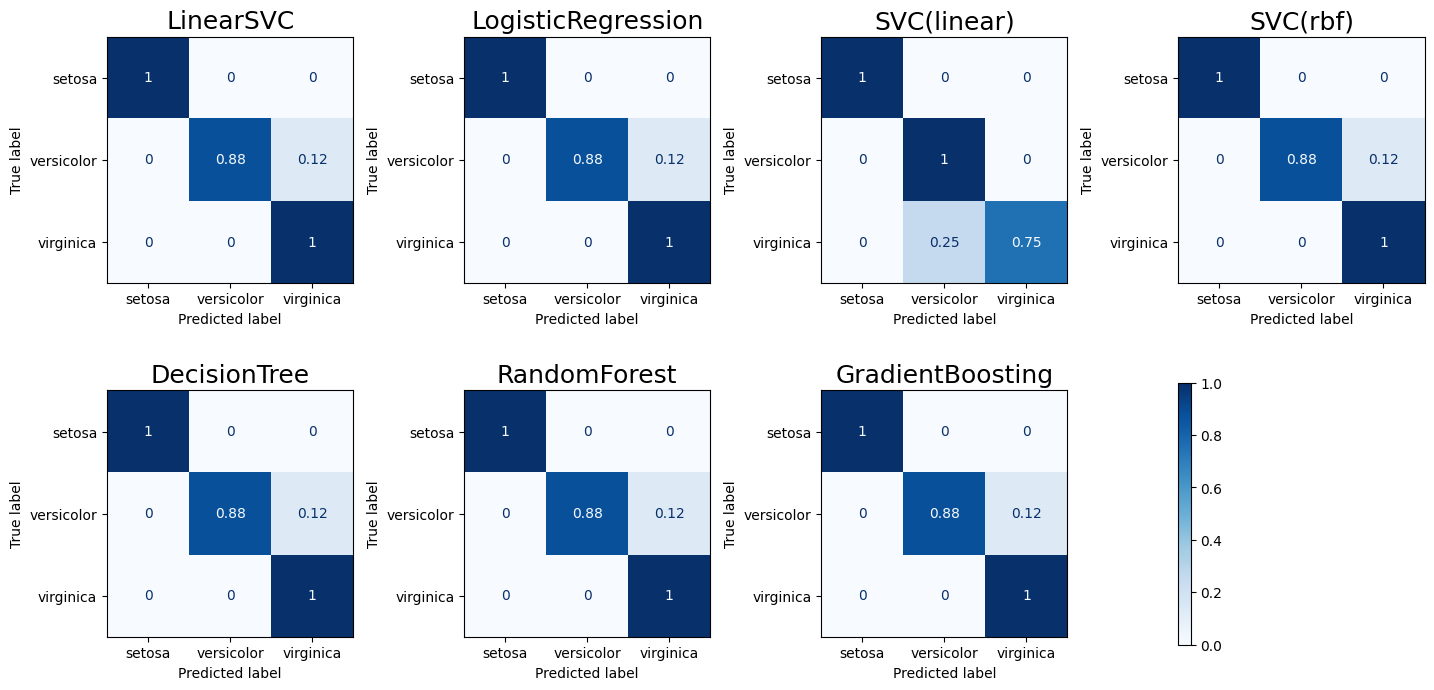

{'setosa': 10, 'versicolor': 8, 'virginica': 12}


In [4]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.


# import some data to play with
iris = load_iris()
# Selected features: petal length and petal width
X, y = iris.data, iris.target
class_names = iris.target_names

X, y = shuffle(X, y, random_state=0)

names = [
    "LinearSVC",
    "LogisticRegression",
    "SVC(linear)",
    "SVC(rbf)",
    "DecisionTree",
    "RandomForest",
    "GradientBoosting",
]

    
classifiers = [
    LinearSVC(dual='auto', max_iter=2000, random_state=0),
    LogisticRegression(max_iter=5000, random_state=0),
    SVC(kernel="linear", C=0.025, random_state=0),
    SVC(kernel='rbf', gamma=2, C=1, random_state=0),
    DecisionTreeClassifier(max_depth=5, random_state=0),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=None, random_state=0),    #max_features=1
    GradientBoostingClassifier(learning_rate=0.1, random_state=0),
]

# Split the data into a training set and a test set
train_size = 0.8
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=0)

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# Run classifier, using a model that is too regularized (C too low) to see
# the impact on the results
# classifier = svm.SVC(kernel="linear", C=0.01).fit(X_train, y_train)

np.set_printoptions(precision=3)

cols = 4
rows = math.ceil(len(classifiers) / cols)
fig, subs = plt.subplots(rows, cols, figsize=(cols*4+1, rows*4))
axes = subs.flatten()

i = 0
for name, clf in zip(names, classifiers):
    ax = axes[i]
    
    classifier = clf.fit(X_train, y_train)
    disp = ConfusionMatrixDisplay.from_estimator(
        classifier,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        ax=ax,
        colorbar=False,
        normalize="true",
        # normalize=None,
    )
    ax.set_title(name, size=18)
    i += 1

#
# Show the colorbar in the last subplot
axins = axes[-1].inset_axes([0, 0, 0.05, 1],)
fig.colorbar(disp.im_, cax=axins, location='left', ticklocation='right')
axes[-1].set_frame_on(False)
axes[-1].set_axis_off()
plt.subplots_adjust(hspace=0.35, wspace=0.45)
plt.show()

classes, counts = np.unique(class_names[y_test], return_counts=True)
# Combine into a dictionary for easy reading
result = dict(zip(classes, counts))
print(result)


Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4


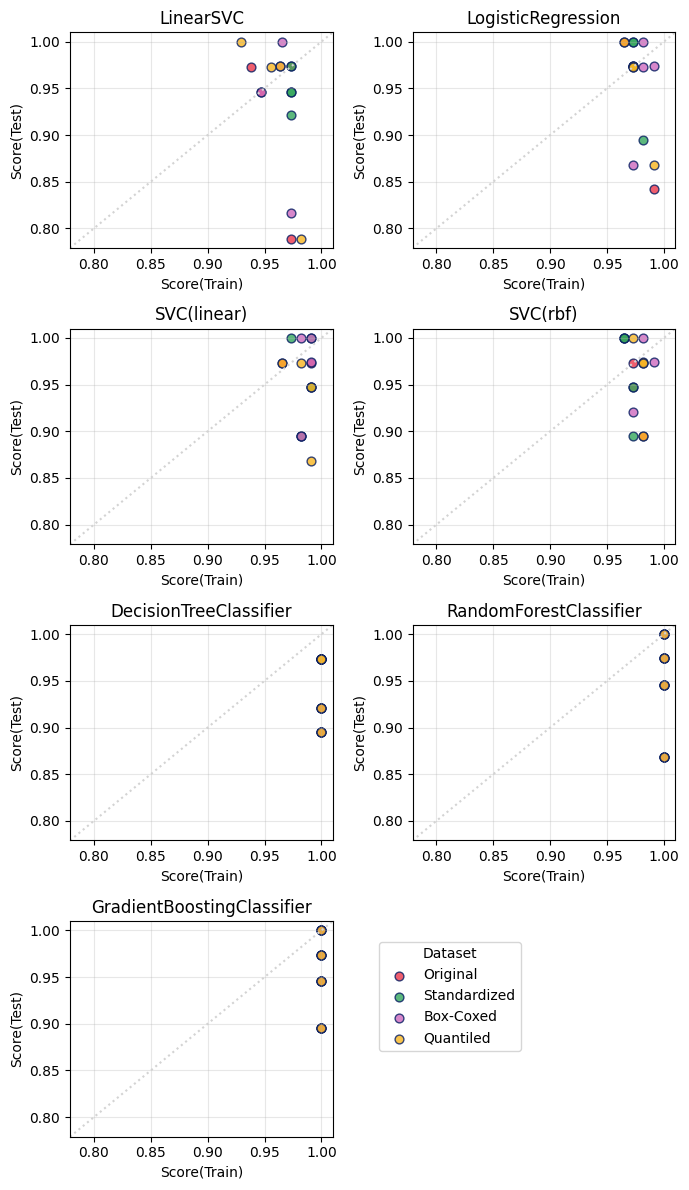

Box-Coxed
                            Score(Train)  Score(Test)    Acc
Model                                                       
DecisionTreeClassifier             1.000        0.940  0.985
GradientBoostingClassifier         1.000        0.954  0.988
LinearSVC                          0.958        0.920  0.948
LogisticRegression                 0.976        0.947  0.968
RandomForestClassifier             1.000        0.947  0.987
SVC(linear)                        0.982        0.947  0.974
SVC(rbf)                           0.973        0.954  0.968
Original
                            Score(Train)  Score(Test)    Acc
Model                                                       
DecisionTreeClassifier             1.000        0.940  0.985
GradientBoostingClassifier         1.000        0.954  0.988
LinearSVC                          0.973        0.947  0.967
LogisticRegression                 0.975        0.967  0.973
RandomForestClassifier             1.000        0.947  0.987
SVC(l

In [4]:

def modelpredict(dfmodel, xtrain, xtest, ytrain, ytest):
    modellist = dfmodel.Name.unique().tolist()
    evalres = []
    # modellist.sort()

    #
    # Instantiate a ClassifierFactory
    mf = ClassifierFactory()

    for name in modellist:
        # Extract the hyperparameters for the specific model
        dfparam = dfmodel.loc[dfmodel.Name == name, :]
        hparam_dict = dict(zip(dfparam.Hyperparameter, dfparam.Value))  
        # Create a model instance
        model, desc = mf.newclassifier(name, hparam_dict)

        if model is not None:
            # Fit and evaluate the model
            scoremodel, acctrain, acctest, accall = mf.execute(model, xtrain, ytrain, xtest, ytest)
        else:
            scoremodel, acctrain, acctest, accall = None, None, None, None

        # Append this particular model's execution results to the result list
        evalres.append([name, scoremodel, acctrain, acctest, accall])
        
    return evalres


ModelCols = ['Name', 'Category', 'PreCalc', 'Hyperparameter', 'Value']
#
# Model candidates and their default hyperparameters
ModelList=[
    ['LinearSVC',                    'Classification', 0, 'random_state', 0],
    ['LinearSVC',                    'Classification', 0, 'max_iter', 2000],
    
    ['LogisticRegression',           'Classification', 0, 'max_iter', 5000],
    ['LogisticRegression',           'Classification', 0, 'random_state', 0],

    ['SVC(linear)',                  'Classification', 0, 'random_state', 0],
    ['SVC(linear)',                  'Classification', 0, 'max_iter', 2000],     
    ['SVC(rbf)',                     'Classification', 0, 'random_state', 0],
    ['SVC(rbf)',                     'Classification', 0, 'max_iter', 2000],
    
    ['DecisionTreeClassifier',       'Classification', 0, 'criterion', 'gini'],
    ['DecisionTreeClassifier',       'Classification', 0, 'max_depth', None],
    ['DecisionTreeClassifier',       'Classification', 0, 'random_state', 0],    
    
    ['RandomForestClassifier',       'Classification', 0, 'n_estimators', 200],
    ['RandomForestClassifier',       'Classification', 0, 'random_state', 0],
    
    ['GradientBoostingClassifier',   'Classification', 0, 'learning_rate', 0.1],
    ['GradientBoostingClassifier',   'Classification', 0, 'random_state', 0],
]

df_model = pd.DataFrame(ModelList, columns=ModelCols)

# Load the dataset
iris = load_iris()

features, targets = iris.data, iris.target
feature_names = np.char.title(np.char.replace(iris.feature_names, ' (cm)', ''))
target_names = np.char.title(iris.target_names)
# print( iris.DESCR )

# Shuffle the features and the targets
shuffled_features, shuffled_targets = shuffle(features, targets, random_state=0)

bins = 50, 
ppnone = 'Original'
ppstd = 'Standardized'
pplog1p = 'Log1p'
ppboxcox = 'Box-Coxed'
pppca = 'PCA'
ppquantile = 'Quantiled'
preprocess = [ppnone, 
              ppstd, 
              # pplog1p, 
              ppboxcox,
              # pppca,
              ppquantile]

colors = TABHUELIST[4:20:4]
cmap = dict(zip(preprocess, colors))
refcolor = LIGHTGRAY
edgecolor = EDGECOLOR

dfo = pd.DataFrame(shuffled_features, columns=feature_names)
# print(f'sample of the dataset:\n{dfo.head()}')
# print(dfo.describe())

#
# visualize the input data
# print(f'\n{preprocess[0]}')
# dfo.hist(bins=bins)
# plt.show()

#
# default parameters for data split
pn_splits = 4 # Train-Test = 80/20
prandom_state = 0

# Configure KFold
kf = KFold(n_splits=pn_splits, shuffle=True, random_state=0)

eval_res = None
# Manually iterate through folds
for ite, (train_ind, test_ind) in enumerate(kf.split(shuffled_features)):
    ite += 1
    print('Iteration: {}'.format(ite))
    # print(sorted(train_ind))
    # print(sorted(test_ind))
    eval_ite = None
    
    # Split the dataset into the training set and test set
    x_train, x_test = shuffled_features[train_ind], shuffled_features[test_ind]
    y_train, y_test = shuffled_targets[train_ind], shuffled_targets[test_ind]
    
    # 
    # Preprocess: None, meaning using the original features
    if ppnone in preprocess:
        evalo = modelpredict(df_model, x_train, x_test, y_train, y_test)
        # evalo = np.hstack(np.full((len(evalo), 1), preprocess[0])
        tmpds = np.full((len(evalo), 1), ppnone)
        evalo = np.concatenate((evalo, tmpds), axis=1)
        if eval_ite is None:
            eval_ite = evalo
        else:
            eval_ite = np.vstack([eval_ite, evalo])

    #
    # Preprocess: Standardize the features
    if ppstd in preprocess:
        sc = StandardScaler()
        xs_train = sc.fit_transform(x_train)
        xs_test = sc.transform(x_test)

        xs = np.vstack([xs_train, xs_test])
        dfs = pd.DataFrame(xs, columns=feature_names)
        # print(f'\n{ppstd}')
        # dfs.hist(bins=bins)
        # plt.show()

        evals = modelpredict(df_model, xs_train, xs_test, y_train, y_test)
        tmpds = np.full((len(evals), 1), ppstd)
        evals = np.concatenate((evals, tmpds), axis=1)
        if eval_ite is None:
            eval_ite = evals
        else:
            eval_ite = np.vstack([eval_ite, evals])

    #
    # Preprocess: Transform the features with log1p function
    if pplog1p in preprocess:
        xl_train, xl_test = np.log1p(x_train), np.log1p(x_test)

        xl = np.vstack([xl_train, xl_test])
        dfl = pd.DataFrame(xl, columns=feature_names)
        # print(f'\n{pplog1p}')
        # dfl.hist(bins=bins)
        # plt.show()

        evall = modelpredict(df_model, xl_train, xl_test, y_train, y_test)
        tmpds = np.full((len(evals), 1), pplog1p)
        evall = np.concatenate((evall, tmpds), axis=1)
        if eval_ite is None:
            eval_ite = evall
        else:
            eval_ite = np.vstack([eval_ite, evall])

    #
    # Preprocess: Box-Cox the features
    if ppboxcox in preprocess:
        pt = PowerTransformer(method='box-cox', standardize=True)
        xb_train = pt.fit_transform(x_train)
        xb_test = pt.transform(x_test)

        xb = np.vstack([xb_train, xb_test])
        dfb = pd.DataFrame(xb, columns=feature_names)
        # print(f"Estimated Lambda value: {pt.lambdas_[0]:.4f}")
        # print(f'\n{ppboxcox}')
        # dfb.hist(bins=bins)
        # plt.show()

        evalb = modelpredict(df_model, xb_train, xb_test, y_train, y_test)
        tmpds = np.full((len(evalb), 1), ppboxcox)
        evalb = np.concatenate((evalb, tmpds), axis=1)
        if eval_ite is None:
            eval_ite = evalb
        else:
            eval_ite = np.vstack([eval_ite, evalb])

    #
    # Preprocess: Reduce dimensions using PCA
    if pppca in preprocess:
        pca = PCA(n_components=2)
        xp_train = pca.fit_transform(x_train)
        xp_test = pca.transform(x_test)
        xp = np.vstack([xp_train, xp_test])

        dfp = pd.DataFrame(xp, columns=['Component-1', 'Component-2'])
        # print(f'\n{pppca}')
        # dfp.hist(bins=bins)
        # plt.show()
        evalp = modelpredict(df_model, xp_train, xp_test, y_train, y_test)
        tmpds = np.full((len(evalp), 1), pppca)
        evalp = np.concatenate((evalp, tmpds), axis=1)
        if eval_ite is None:
            eval_ite = evalp
        else:
            eval_ite = np.vstack([eval_ite, evalp])
    
    # n_quantiles is set to the training set size rather than the default value
    # to avoid a warning being raised by this example
    if ppquantile in preprocess:
        qt = QuantileTransformer(
            n_quantiles=len(x_train), 
            output_distribution="normal", 
            random_state=prandom_state
        )
        xq_train = qt.fit_transform(x_train)
        xq_test = qt.transform(x_test)
        xq = np.vstack([xq_train, xq_test])
        dfq = pd.DataFrame(xq, columns=feature_names)
        # print(f'\n{ppquantile}')
        # dfq.hist(bins=bins)
        # plt.show()

        evalq = modelpredict(df_model, xq_train, xq_test, y_train, y_test)
        tmpds = np.full((len(evalq), 1), ppquantile)
        evalq = np.concatenate((evalq, tmpds), axis=1)
        if eval_ite is None:
            eval_ite = evalq
        else:
            eval_ite = np.vstack([eval_ite, evalq])

    #
    # Consolidate the results at fold ite
    itercol = np.ones((len(eval_ite), 1), dtype=np.int16) * ite
    eval_ite = np.hstack([itercol, eval_ite])
                      
    if eval_res is None:
        eval_res = eval_ite
    else:
        eval_res = np.vstack([eval_res, eval_ite])

# Format the execution results matrix using DataFrame
columns = ['Fold', 'Model', 'Score', 'Score(Train)', 'Score(Test)', 'Acc', 'Dataset']
df_res = pd.DataFrame(eval_res, columns=columns)

df_res['Fold'] = df_res['Fold'].astype(int)

floatcols = ['Score', 'Score(Train)', 'Score(Test)', 'Acc']
df_res[floatcols] = df_res[floatcols].astype(float)
df_res[floatcols] = df_res[floatcols].round(3)

df_res['Index'] = df_res.index

fig, subs = plt.subplots(nrows=4, ncols=2, figsize=(7, 12))    #, layout="constrained")
axes = subs.flatten()
modellist = df_model.Name.unique().tolist()

x_min = df_res[['Score(Train)', 'Score(Test)']].values.min() - 0.01
x_max = df_res[['Score(Train)', 'Score(Test)']].values.max() + 0.01
y_min, y_max = x_min, x_max

for i, model in enumerate(modellist):
    dfmod = df_res[df_res.Model==model]
    
    for pp, group in dfmod.groupby('Dataset'):
        axes[i].scatter(x=group['Score(Train)'], y=group['Score(Test)'],
                        c=cmap.get(pp),
                        edgecolor=edgecolor,
                        alpha = 0.8,
                        label=pp,
                        s=40)
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    axes[i].plot((x_min, x_max), (y_min, y_max),
                 color=refcolor,
                 linestyle=':',
                 # alpha=0.4,
                )
        
    axes[i].set_xlabel('Score(Train)')
    axes[i].set_ylabel('Score(Test)')
    axes[i].set_title(model)
    axes[i].grid(alpha=0.3)
    
    i += 1

fig.legend(title='Dataset',
           loc=(0.55, 0.117),
           # loc='lower right', 
           labels=df_res['Dataset'].unique().tolist(),
          )

axes[-1].set_frame_on(False)
axes[-1].set_axis_off()

plt.tight_layout()
plt.show()

cols = ['Score(Train)', 'Score(Test)', 'Acc']
for pp, group in df_res.groupby("Dataset"):
    dftmp = group.groupby('Model')[cols]
    # dftmp.mean()
    print(pp)
    print(dftmp.mean().round(3))
    
# Export the execution results to the Excel file, including all models and all folds
#   Replace the sheet if it exists
# file_path = "Iris_Classification.xlsx"
# sheetname = 'CompareClassifiers'
# with pd.ExcelWriter(file_path, 
#                     engine='openpyxl', 
#                     mode='a', 
#                     if_sheet_exists='replace') as writer:
#     df_res.to_excel(writer, sheet_name=sheetname, index=False)


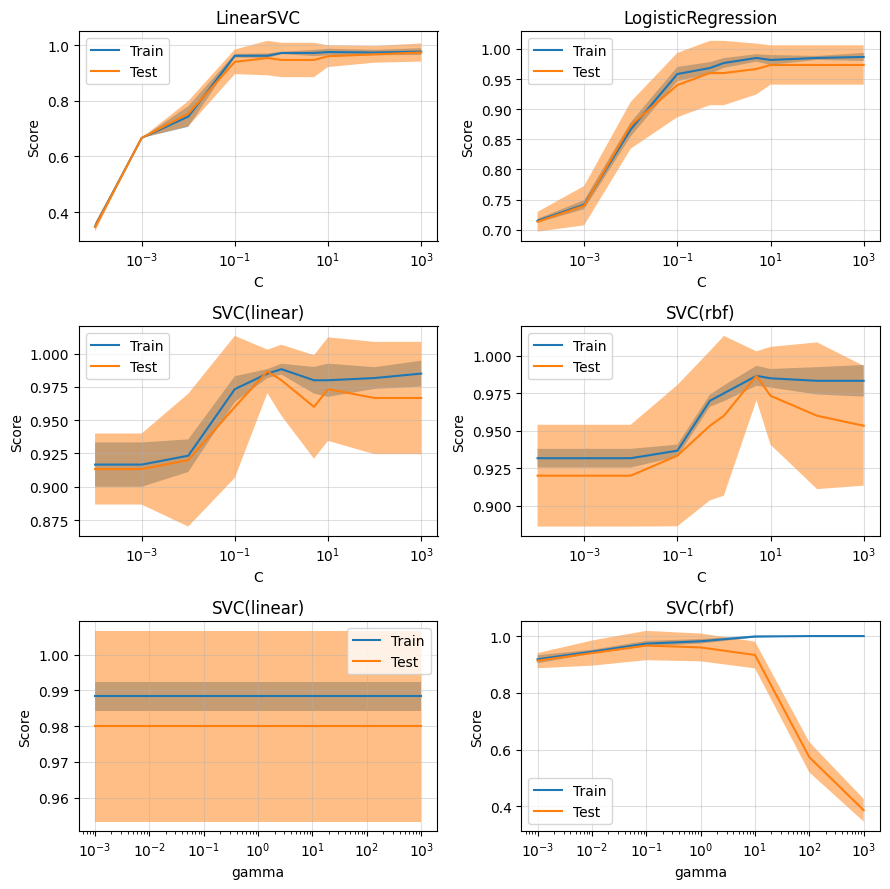

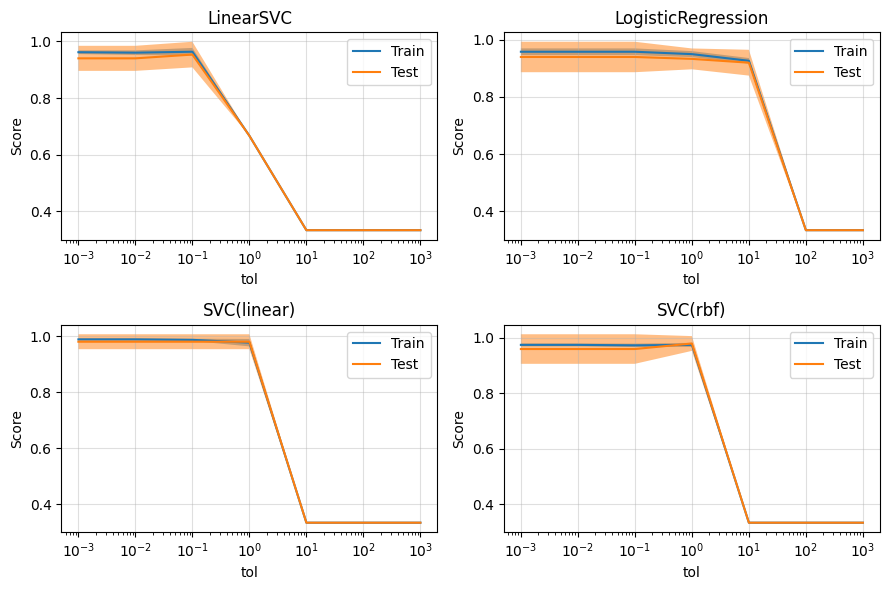

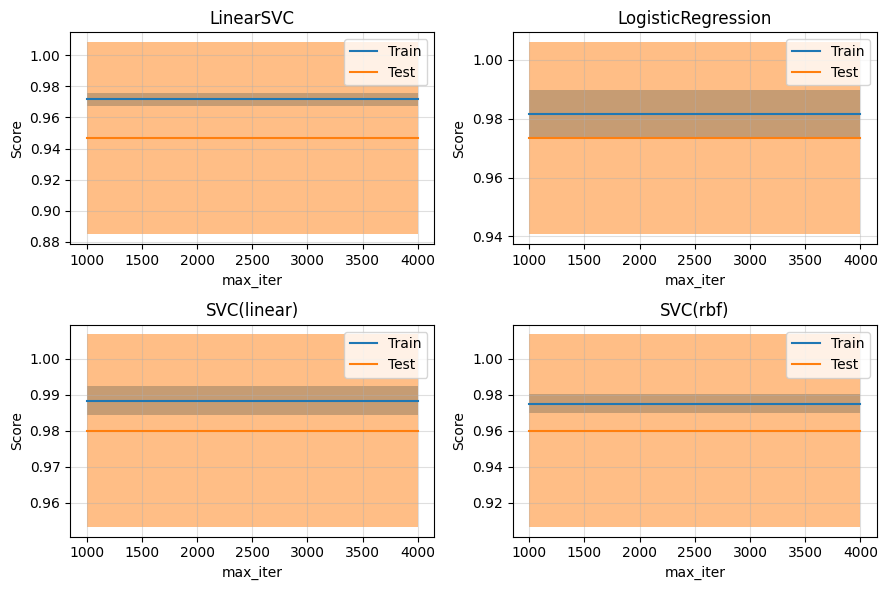

In [5]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

X, y = load_iris(return_X_y=True)
X, y = shuffle(X, y, random_state=0)

fig, subs = plt.subplots(3, 2, figsize=(9, 9))
axes = subs.flatten()
#
# C
ValidationCurveDisplay.from_estimator(
   LinearSVC(dual='auto'), X, y, 
    param_name="C", 
    # param_range=np.logspace(-7, 4, 10),
    param_range=np.array([0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100, 1000]),
    ax=axes[0],
)
axes[0].grid(alpha=0.4)
axes[0].set_title('LinearSVC')

ValidationCurveDisplay.from_estimator(
   LogisticRegression(max_iter=3000), X, y, 
    param_name="C", 
    # param_range=np.logspace(-7, 4, 10),
    param_range=np.array([0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100, 1000]),
    ax=axes[1],
)
axes[1].grid(alpha=0.4)
axes[1].set_title('LogisticRegression')

ValidationCurveDisplay.from_estimator(
   SVC(kernel="linear"), X, y, 
    param_name="C", 
    # param_range=np.logspace(-7, 4, 10),
    param_range=np.array([0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100, 1000]),
    # cmap=ListedColormap(TABHUELIST[0:20:9]),
    ax=axes[2],
)
axes[2].grid(alpha=0.4)
axes[2].set_title('SVC(linear)')

ValidationCurveDisplay.from_estimator(
   SVC(kernel="rbf"), X, y, 
    param_name="C",
    #np.logspace(-7, 4, 10),
    param_range=np.array([0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100, 1000]),
    ax=axes[3], 
    std_display_style='fill_between'
)
axes[3].grid(alpha=0.4)
axes[3].set_title('SVC(rbf)')

#
# gamma
ValidationCurveDisplay.from_estimator(
   SVC(kernel="linear"), X, y, 
    param_name="gamma", 
    param_range=np.logspace(-3, 3, 7),
    # cmap=ListedColormap(TABHUELIST[0:20:9]),
    ax=axes[4],
)
axes[4].grid(alpha=0.4)
axes[4].set_title('SVC(linear)')

ValidationCurveDisplay.from_estimator(
   SVC(kernel="rbf"), X, y, 
    param_name="gamma", 
    param_range=np.logspace(-3, 3, 7),
    ax=axes[5], 
    std_display_style='fill_between'
)
axes[5].grid(alpha=0.4)
axes[5].set_title('SVC(rbf)')

plt.tight_layout()
plt.show()

# tol: tolerance for stopping criteria
fig, subs = plt.subplots(2, 2, figsize=(9, 6))
axes = subs.flatten()

ValidationCurveDisplay.from_estimator(
   LinearSVC(dual='auto', C=0.1), X, y,
    param_name="tol", 
    param_range=np.logspace(-3, 3, 7),    #default: 0.0001
    ax=axes[0],
)
axes[0].grid(alpha=0.4)
axes[0].set_title('LinearSVC')

ValidationCurveDisplay.from_estimator(
   LogisticRegression(max_iter=3000, C=0.1), X, y, 
    param_name="tol", 
    param_range=np.logspace(-3, 3, 7),    #default: 0.0001
    ax=axes[1],
)
axes[1].grid(alpha=0.4)
axes[1].set_title('LogisticRegression')

ValidationCurveDisplay.from_estimator(
    SVC(kernel="linear", C=1.0), X, y, 
    param_name="tol", 
    param_range=np.logspace(-3, 3, 7),    #default: 0.001
    ax=axes[2],
)
axes[2].grid(alpha=0.4)
axes[2].set_title('SVC(linear)')

ValidationCurveDisplay.from_estimator(
    SVC(kernel="rbf", C=1.0), X, y, 
    param_name="tol", 
    param_range=np.logspace(-3, 3, 7),    #default: 0.001
    ax=axes[3],
)
axes[3].grid(alpha=0.4)
axes[3].set_title('SVC(rbf)')

plt.tight_layout()
plt.show()

# max iterations
fig, subs = plt.subplots(2, 2, figsize=(9, 6))
axes = subs.flatten()
ValidationCurveDisplay.from_estimator(
   LinearSVC(dual='auto', C=1), X, y, 
    param_name="max_iter", 
    param_range=[1000, 2000, 3000, 4000],
    ax=axes[0],
)
axes[0].grid(alpha=0.4)
axes[0].set_title('LinearSVC')

ValidationCurveDisplay.from_estimator(
   LogisticRegression(C=10), X, y, 
    param_name="max_iter", 
    param_range=[1000, 2000, 3000, 4000],
    ax=axes[1],
)
axes[1].grid(alpha=0.4)
axes[1].set_title('LogisticRegression')

ValidationCurveDisplay.from_estimator(
   SVC(kernel="linear", C=1.0), X, y, 
    param_name="max_iter",
    param_range=[1000, 2000, 3000, 4000],
    ax=axes[2], 
    std_display_style='fill_between'
)
axes[2].grid(alpha=0.4)
axes[2].set_title('SVC(linear)')

ValidationCurveDisplay.from_estimator(
   SVC(kernel="rbf", C=1.0), X, y, 
    param_name="max_iter",
    param_range=[1000, 2000, 3000, 4000],
    ax=axes[3], 
    std_display_style='fill_between'
)
axes[3].grid(alpha=0.4)
axes[3].set_title('SVC(rbf)')

# plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.tight_layout()
plt.show()

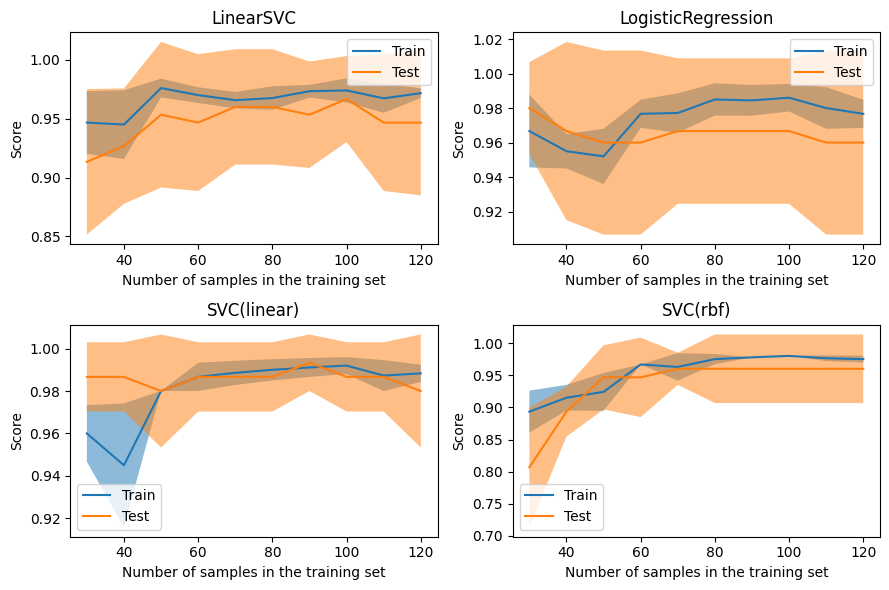

In [7]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

# 
# Learning Curve
X, y = load_iris(return_X_y=True)
X, y = shuffle(X, y, random_state=0)

fig, subs = plt.subplots(2, 2, figsize=(9, 6))
axes = subs.flatten()

LearningCurveDisplay.from_estimator(
    LinearSVC(dual='auto'), 
    X, y, train_sizes=[30, 40, 50, 60, 70, 80, 90, 100, 110, 120], cv=5, 
    # shuffle=True, random_state=0,
    ax=axes[0])
axes[0].set(title='LinearSVC')

LearningCurveDisplay.from_estimator(
    LogisticRegression(max_iter=3000), 
    X, y, train_sizes=[30, 40, 50, 60, 70, 80, 90, 100, 110, 120], cv=5, 
    # shuffle=True, random_state=0,
    ax=axes[1])
axes[1].set(title='LogisticRegression')

LearningCurveDisplay.from_estimator(
    SVC(kernel="linear"), 
    X, y, train_sizes=[30, 40, 50, 60, 70, 80, 90, 100, 110, 120], cv=5, 
    # shuffle=True, random_state=0,
    ax=axes[2],
    # std_display_style="errorbar"
)
axes[2].set(title='SVC(linear)')

LearningCurveDisplay.from_estimator(
    SVC(kernel="rbf"), 
    X, y, train_sizes=[30, 40, 50, 60, 70, 80, 90, 100, 110, 120], cv=5, 
    # shuffle=True, random_state=0,
    ax=axes[3])
axes[3].set(title='SVC(rbf)')

plt.tight_layout()
plt.show()

120 allocated for training; 30 allocated for test
                 Dataset               Model  Score(Train)  Score(Test)
0       Original Dataset           LinearSVC         0.967        0.933
1       Original Dataset  LogisticRegression         0.992        0.967
2       Original Dataset  SVC(kernel=linear)         0.992        0.967
3       Original Dataset     SVC(kernel=rbf)         0.983        0.967
4   Standardized Dataset           LinearSVC         0.967        0.967
5   Standardized Dataset  LogisticRegression         0.983        0.967
6   Standardized Dataset  SVC(kernel=linear)         0.983        0.967
7   Standardized Dataset     SVC(kernel=rbf)         0.975        0.967
8      Box-Coxed Dataset           LinearSVC         0.967        0.967
9      Box-Coxed Dataset  LogisticRegression         0.983        0.967
10     Box-Coxed Dataset  SVC(kernel=linear)         0.983        0.967
11     Box-Coxed Dataset     SVC(kernel=rbf)         0.992        0.967
12     Quantil

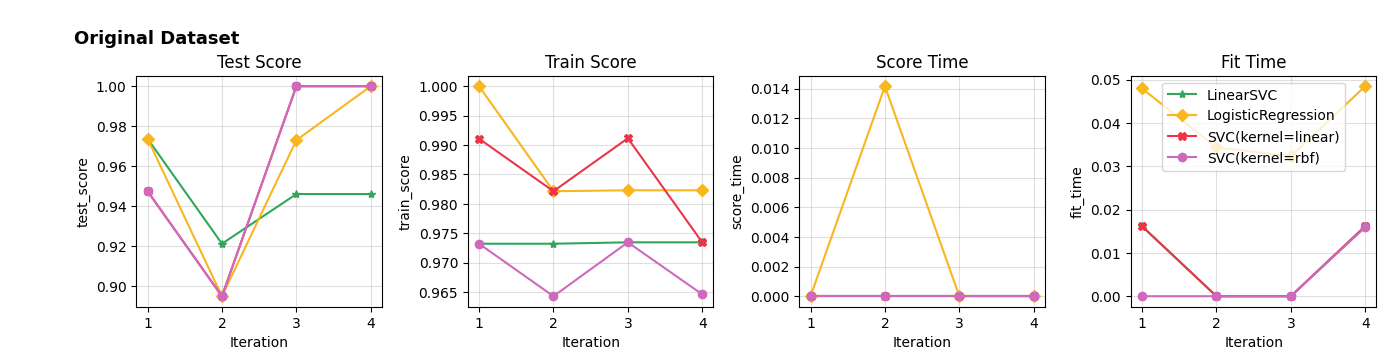

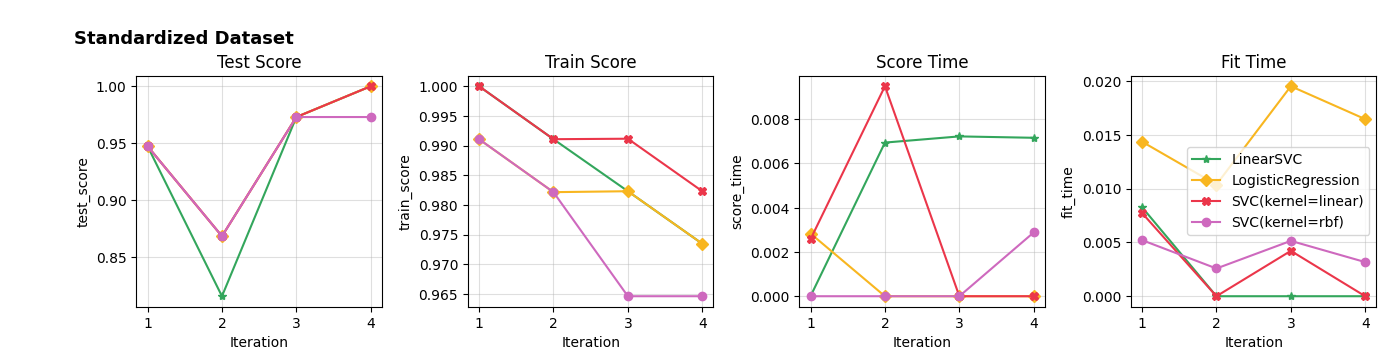

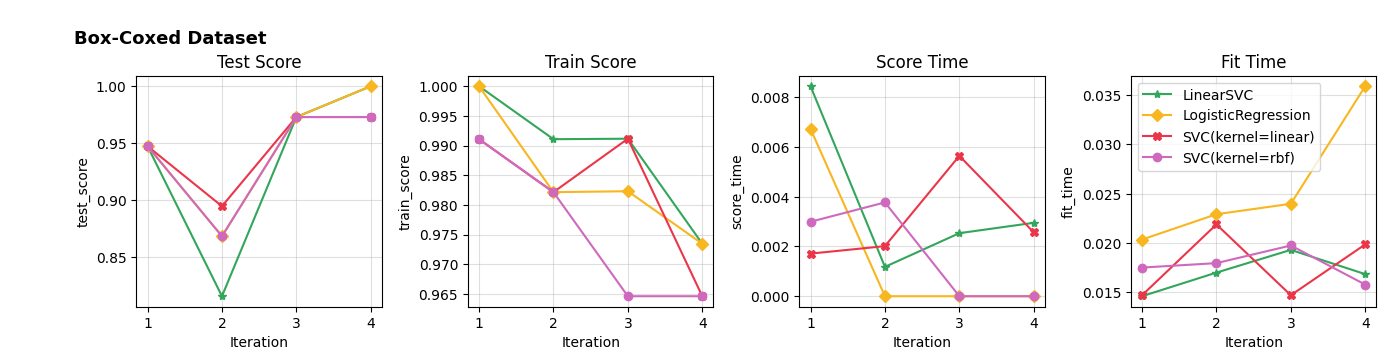

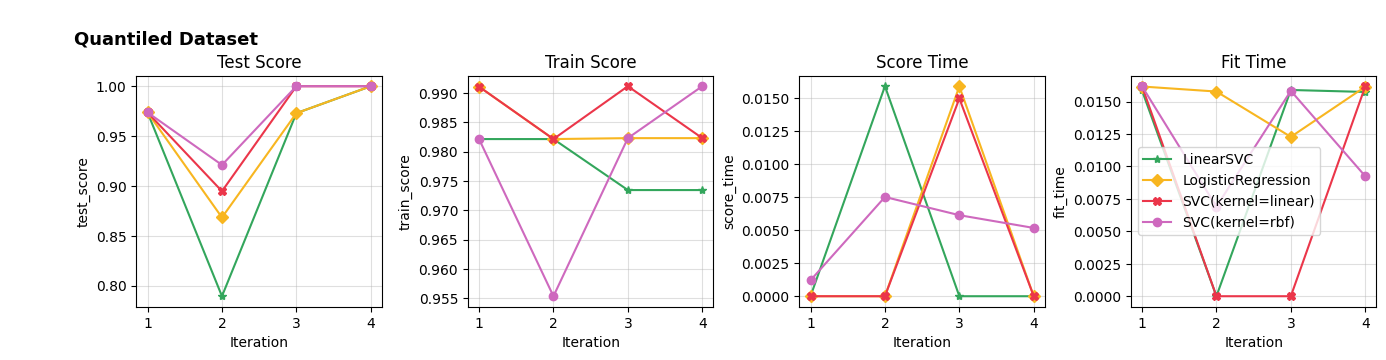

In [2]:
# Copyright (c) 2007-2026 The scikit-learn developers.
# All rights reserved.

#
# Exaustive GridSearch

# Load Iris dataset
iris = load_iris()

features, targets = iris.data, iris.target
feature_names = np.char.title(np.char.replace(iris.feature_names, ' (cm)', ''))
target_names = np.char.title(iris.target_names)

# No. of cross validation folds
pcv = 5
# Random state for the data split function and the models
prandom_state = 0

shuffled_X, shuffled_y = shuffle(
    features, 
    targets, 
    random_state=prandom_state)
train_sets = [120]
# random.sample picks random numbers without a duplication
random.seed(prandom_state)
ind_trains = [random.sample(range(0, 149), num) for num in train_sets]
fullset = np.arange(0, 150)
ind_tests = [list(set(fullset)-set(inds)) for inds in ind_trains]
    

class ProcessNone():
    def fit(self, X, y=None, kwargs=None):
        return self
    def transform(self, X, copy=None):
        return X
    def fit_transform(self, X, y=None):
        return X
    
preprocesses = {
    "Original Dataset": ProcessNone(),
    "Standardized Dataset": StandardScaler(),
    "Box-Coxed Dataset": PowerTransformer(
        method='box-cox', 
        standardize=True),
    "Quantiled Dataset": QuantileTransformer(
        n_quantiles=min(train_sets), 
        output_distribution="normal", 
        random_state=prandom_state),
}

models = {
    "LinearSVC": LinearSVC(dual='auto', max_iter=10000, random_state=prandom_state),
    "LogisticRegression": LogisticRegression(random_state=prandom_state, max_iter=1000),
    "SVC(kernel=linear)": SVC(kernel='linear', max_iter=-1, random_state=prandom_state),   #20000
    "SVC(kernel=rbf)": SVC(kernel="rbf", max_iter=-1, random_state=prandom_state),    #1000
}

# Define a grid of hyperparameters
param_grids = {
    "LinearSVC": {
        'C': np.logspace(-3, 3, 7),
    },
    "LogisticRegression": {
        'C': np.logspace(-3, 3, 7),
    },
    "SVC(kernel=linear)": {
        'C': np.logspace(-3, 3, 7),
    },
    "SVC(kernel=rbf)": {
        'C': np.logspace(-3, 3, 7),
        'gamma': np.logspace(-3, 1, 5),
    },
}

results = []
for ind_train, ind_test in zip(ind_trains, ind_tests):
    X_train, y_train = shuffled_X[ind_train], shuffled_y[ind_train]
    X_test, y_test = shuffled_X[ind_test], shuffled_y[ind_test]

    num_train = len(X_train)
    num_test = len(X_test)
    strsetsize = f"{num_train} allocated for training; {num_test} allocated for test"
    print(strsetsize)
    # print(sorted(ind_train))
    # print(sorted(ind_test))

    for ppname, preprocess in preprocesses.items():
        for modname, model in models.items(): 
            # print(ppname + "  --  " + modname)
    
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grids[modname],
                return_train_score=True,
                scoring='accuracy',
                cv=pcv,
                n_jobs=-1,
                # verbose=2,
            )

            pl = Pipeline(steps=
                [("preprocess", preprocess),
                 ("gridsearch", grid_search),
                ]
            )
            pl.fit(X_train, y_train)
            gs = pl["gridsearch"]
            gsbest = gs.best_estimator_
            gsscore = gs.best_score_

            # print(f"Best parameters found: {gs.best_params_}")
            # print(f"Best estimator found: {gsbest}")
            # print(f"Best cross-validation score: {gsscore}")

            # Evaluate the model on the train set
            X_train_trans = preprocess.transform(X_train)
            y_train_pred = gsbest.predict(X_train_trans)
            score_train = accuracy_score(y_train, y_train_pred)
            # print(f'Train score: {score_train:.3f}')

            # Evaluate the optimized model on the test set
            y_test_pred = gsbest.predict(preprocess.transform(X_test))
            score_test = accuracy_score(y_test, y_test_pred)
            # print(f'Test score: {score_test:.3f}')
           
            result = [ppname, modname, gsbest, gsscore, score_train, score_test]          
            results.append(result)

cols = ["Dataset", "Model", "BestEstimator", "BestScore", "Score(Train)", "Score(Test)"]
dfgsres = pd.DataFrame(results, columns=cols)
dfgsres = dfgsres.round(3)
print(dfgsres[["Dataset", "Model", "Score(Train)", "Score(Test)"]])

#
# Cross validation
kf = KFold(n_splits=4, shuffle=True, random_state=0)

preprocesses = {
    "Original Dataset": ProcessNone(),
    "Standardized Dataset": StandardScaler(),
    "Box-Coxed Dataset": PowerTransformer(
        method='box-cox', 
        standardize=True),
    "Quantiled Dataset": QuantileTransformer(
        n_quantiles=112, 
        output_distribution="normal", 
        random_state=prandom_state),
}

dfcvres = None
for pp, dsgroup in dfgsres.groupby("Dataset"):
    dfmods = None
    for modname, modgroup in dsgroup.groupby("Model"):
        # print(f'{pp} - {modname}')
        bestclf = modgroup["BestEstimator"].values.any()
        
        modpl = make_pipeline(
            preprocesses[pp],
            bestclf
        )
        scores = cross_validate(modpl,
                                shuffled_X, shuffled_y, 
                                # X_train, y_train,
                                scoring='accuracy',
                                cv=kf,
                                return_train_score=True,
                               )
        dfcv = pd.DataFrame(scores)
        dfcv["Iteration"] = dfcv.index + 1
        dfcv["Model"] = modname
        dfcv["BestEstimator"] = bestclf
        if dfmods is None:
            dfmods = dfcv.copy()
        else:
            dfmods = pd.concat([dfmods, dfcv], axis=0)
        
    dfmods["Dataset"] = pp
    if dfcvres is None:
        dfcvres = dfmods.copy()
    else:
        dfcvres = pd.concat([dfcvres, dfmods], axis=0)
# print(dfcvres.head())

#
# Visualization
colors={"LinearSVC": TABHUELIST[4+0*4], 
         "LogisticRegression": TABHUELIST[4+1*4], 
         "SVC(kernel=linear)": TABHUELIST[4+2*4], 
         "SVC(kernel=rbf)": TABHUELIST[4+3*4]}
msize = 6
markers={"LinearSVC": "*", 
         "LogisticRegression": "D", 
         "SVC(kernel=linear)": "X", 
         "SVC(kernel=rbf)": "o"}

dsorder = {
    "Original Dataset": 1,
    "Standardized Dataset": 2,
    "Box-Coxed Dataset": 3,
    "Quantiled Dataset": 4,
}
#
# Rearrange column order
cols = ['Dataset', 'Model', 'Iteration', 'train_score', 'test_score', 'fit_time', 'score_time', 'BestEstimator']
dfcvres = dfcvres[cols]
for pp, idx in dsorder.items():
    # print(pp, ' ', idx)
    dfmods = dfcvres.query("Dataset==@pp")

    fig, subs = plt.subplots(nrows=1, ncols=4,
                             figsize=(16, 3))
    axes = subs.flatten()

    row = 0
    for modname, group in dfmods.groupby('Model'):    
        axes[row].plot(
            "Iteration",
            "test_score",
            data=group,
            c=colors[modname],
            marker=markers[modname],
            markersize=msize,
            label=modname,
        )
        axes[row].set_title("Test Score")
        axes[row].set_xlabel("Iteration")
        axes[row].set_ylabel("test_score")
        axes[row].grid(alpha=0.4)    #which='major', 
    
        axes[row+1].plot(
            "Iteration",
            "train_score",
            data=group,
            c=colors[modname],
            marker=markers[modname],
            markersize=msize,
            label=modname,
        )
        axes[row+1].set_title("Train Score")
        axes[row+1].set_xlabel("Iteration")
        axes[row+1].set_ylabel("train_score")
        axes[row+1].grid(alpha=0.4)    #which='major', 
        
        axes[row+2].plot(
            "Iteration",
            "score_time",
            data=group,
            c=colors[modname],
            marker=markers[modname],
            markersize=msize,
            label=modname,
        )
        axes[row+2].set_title("Score Time")
        axes[row+2].set_xlabel("Iteration")
        axes[row+2].set_ylabel("score_time")
        axes[row+2].grid(alpha=0.4)    #which='major',

        axes[row+3].plot(
            "Iteration",
            "fit_time",
            data=group,
            c=colors[modname],
            marker=markers[modname],
            markersize=msize,
            label=modname,
        )
        axes[row+3].set_title("Fit Time")
        axes[row+3].set_xlabel("Iteration")
        axes[row+3].set_ylabel("fit_time")
        axes[row+3].grid(alpha=0.4)    #which='major',
        axes[row+3].legend()
    
    fig.suptitle(t="", ha='right', va='top')
    axes[row].annotate(pp,
            xy=(.046, 1.1), xycoords='figure fraction',
            ha='left', va='top',
            fontweight="bold",
            fontsize=13)
    # plt.tight_layout()
    plt.subplots_adjust(wspace=0.35, hspace=0)
    plt.show()


# Export to the Excel file
file_path = "Iris_Classification.xlsx"
valbestmods = 'EvalBestModels'
gsbestmods = 'GSearchBestModels'
with pd.ExcelWriter(file_path, 
                    engine='openpyxl', 
                    mode='a', 
                    if_sheet_exists='replace') as writer:
    dfcvres.to_excel(writer, sheet_name=valbestmods, index=False)
    dfgsres.to_excel(writer, sheet_name=gsbestmods, index=False)
